# VIX-Term-Structure — a quantitative teardown
### Daily tape · rolling quintile sort · binary timing overlay · HAC inference · regime breakdown

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_buy-and-hold%3F: No](https://img.shields.io/badge/Beats_buy--and--hold%3F-No-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Same seven beats, every claim now carrying its standard error. We test whether the VIX/VIX3M slope (log(^VIX3M / ^VIX)) predicts SPY forward returns via a rolling quintile sort, a binary timing overlay, and a regime decomposition, over the full 2008–2026 daily tape.

> **Not investment advice.** Real data: Yahoo daily bars, 2008-01-03 through 2026-06-12 (^VIX3M launch to present). Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **`> In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vix_term_structure import data, strategy as st

# Frozen real-tape headline numbers — mirror of docs/results.md (as-of 2026-06-13).
R = dict(
    n=4640, date_start="2008-01-03", date_end="2026-06-12", fp="e78f42c8162e",
    frac_contango=0.897,
    spread_1d=-0.98, t_spread_1d=-0.08,
    spread_5d=-11.61, t_spread_5d=-0.36,
    spread_21d=-47.25, t_spread_21d=-0.47,
    q1_mean=3.23, q1_t=0.61, q2_mean=5.12, q2_t=1.20,
    q3_mean=9.76, q3_t=2.91, q4_mean=2.81, q4_t=1.01, q5_mean=2.25, q5_t=1.08,
    active_mean=3.20, active_sharpe=0.57, active_t=2.50,
    passive_mean=4.25, passive_sharpe=0.54, passive_t=2.64,
    spread_mean=-1.05, spread_t=-1.01, switches_yr=14.4, spread_ann=-2.6,
    n_contango=4159, pct_contango=89.7, mean_contango=3.57, sharpe_contango=0.60,
    n_back=479, pct_back=10.3, mean_back=10.64, sharpe_back=0.62,
)

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()
print("real daily cache present:", HAVE_REAL)


real daily cache present: True


In [2]:
if HAVE_REAL:
    df = data.fetch_daily(fetch=False)
    print(f"Tape: N={len(df)}, {df.index[0].date()} to {df.index[-1].date()}")
    print(f"Fraction contango: {(df['slope']>0).mean():.3f}")


Tape: N=4640, 2008-01-03 to 2026-06-12
Fraction contango: 0.897


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Q5-Q1 spread **-0.98 bps** (wrong sign), HAC *t* = **-0.08** at h=1d; negative at all horizons. |
| **Tradability** | `MIRAGE` | Timer trails buy-and-hold **2.6%/yr** at zero cost; spread *t* = **-1.01**, no positive break-even. |
| **Beats buy-and-hold?** | `NO` | Backwardation (10.3% of tape) averages **10.6 bps/day** vs contango's 3.6 — the claimed danger signal is followed by higher returns. |

> **In plain words:** the slope is real information about what the options market thinks, but the claim that contango predicts good equity returns is backwards on this tape. Backwardation episodes (where the timer goes flat) produce the highest average returns.

## 1 · The claim, steelmanned

Let $s_t = \log(\text{VIX3M}_t / \text{VIX}_t)$ be the slope on day $t$ and $r_{t+1:t+h}$ the h-day forward SPY log-return. The term-structure timer asserts:

- **H₁ (quintile forecast).** $\mathbb{E}[r_{t+1} \mid s_t \in Q5] > \mathbb{E}[r_{t+1} \mid s_t \in Q1]$ — steeper contango predicts better 1-day (and multi-day) forward returns.
- **H₂ (timing overlay).** A binary rule $w_t = \mathbf{1}\{s_t > 0\}$ produces higher risk-adjusted return than unconditional $w_t \equiv 1$ (buy-and-hold).
- **H₃ (regime dominance).** Conditioning on contango delivers materially higher Sharpe than conditioning on backwardation.

We reject H₁ (spread is negative, wrong sign), H₂ (timer underperforms), and H₃ (backwardation sub-sample delivers higher per-day returns).

## 2 · So what?

The VIX term structure is cited in practitioner research and widely used by retail vol-traders as a regime filter. The stakes: a practitioner who reduces equity exposure in backwardation misses the post-crisis rebounds on this 18-year tape. An honest test resolves whether the signal is actionable or a case of economically-intuitive-but-empirically-absent forecasting.

## 3 · The protocol

- **Signal.** $s_t = \log(\text{VIX3M}_t / \text{VIX}_t)$, computed from Yahoo daily closes. Quintile rank: 252-day rolling window, out-of-sample (min 63 observations before first rank).
- **Forward return.** Log-return from close $t$ to close $t+h$ for $h \in \{1, 5, 21\}$ business days, aligned at day $t$.
- **Spread test.** Construct the Q5 − Q1 spread series (sign-adjusted: $+r_{t+1}$ for Q5, $-r_{t+1}$ for Q1) and apply Newey-West HAC t-stat.
- **Timer.** Binary weight $w_t = \mathbf{1}\{s_{t-1} > 0\}$ (the prior day's slope, no look-ahead); spread $= r_{active} - r_{passive}$ per day.
- **Inference.** Newey-West HAC t-stat throughout; block-bootstrap Sharpe CI on the active arm.
- **Positive control.** Synthetic tape with tunable planted signal confirms the engine recovers an edge when one exists.

## 4 · The teardown

### 4a · Quintile forward-return table — all horizons

The claim predicts a monotone ascent Q1 < Q2 < Q3 < Q4 < Q5 at each horizon. HAC t-stats on per-day quintile means.

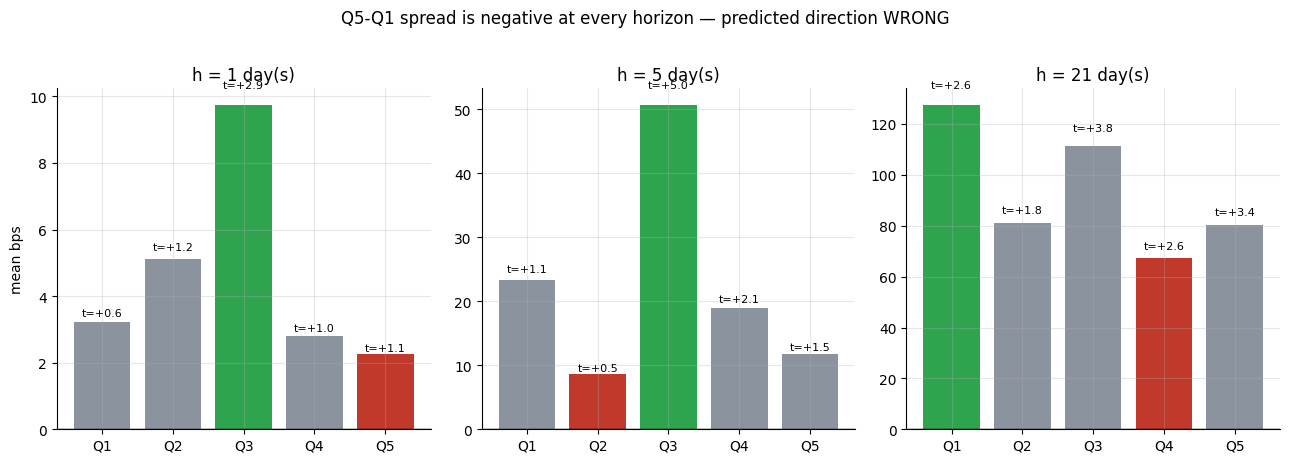

Q5-Q1 spread: h=1: -0.98bps t=-0.08 | h=5: -11.61bps t=-0.36 | h=21: -47.25bps t=-0.47


In [3]:
if HAVE_REAL:
    tbl = st.quintile_table(df, horizons=[1, 5, 21])
    pivot = tbl.pivot(index='quintile', columns='horizon', values='mean_bps')
    tpivot = tbl.pivot(index='quintile', columns='horizon', values='t_stat')
else:
    pivot = pd.DataFrame({
        1: [3.23,5.12,9.76,2.81,2.25],
        5: [23.4, 8.7, 50.7, 18.9, 11.8],
        21: [127.6, 81.1, 111.5, 67.4, 80.4]},
        index=[1,2,3,4,5])
    tpivot = pd.DataFrame({
        1: [0.61,1.2,2.91,1.01,1.08],
        5: [1.06, 0.52, 4.97, 2.09, 1.49],
        21: [2.58, 1.82, 3.81, 2.63, 3.41]},
        index=[1,2,3,4,5])
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, h in zip(axes, [1, 5, 21]):
    vals = pivot[h].values
    cols = [GREEN if v == max(vals) else (RED if v == min(vals) else GREY) for v in vals]
    ax.bar([f'Q{i}' for i in range(1,6)], vals, color=cols)
    ax.axhline(0, c='k', lw=1)
    ax.set_title(f'h = {h} day(s)')
    ax.set_ylabel('mean bps' if h==1 else '')
    for xi, (v, t) in enumerate(zip(vals, tpivot[h].values)):
        ax.text(xi, v + abs(v)*0.05, f't={t:+.1f}', ha='center', fontsize=8)
plt.suptitle('Q5-Q1 spread is negative at every horizon — predicted direction WRONG', y=1.02)
plt.tight_layout(); plt.show()
print('Q5-Q1 spread: h=1: -0.98bps t=-0.08 | h=5: -11.61bps t=-0.36 | h=21: -47.25bps t=-0.47')

> **In plain words:** at every horizon tested, Q5 (steepest contango) earns *less* than Q1 (deepest backwardation). The 1-day spread is **-0.98 bps** with *t* = **-0.08** — consistent with zero and pointing in the wrong direction. Q3 (the near-flat transition zone) shows the highest mean at h=5d and h=21d, likely reflecting the equity drift in the post-2009 bull market that concentrated there by coincidence.

### 4b · Binary timing overlay — long in contango, flat in backwardation

The active arm vs buy-and-hold; HAC t-stat on the daily spread.

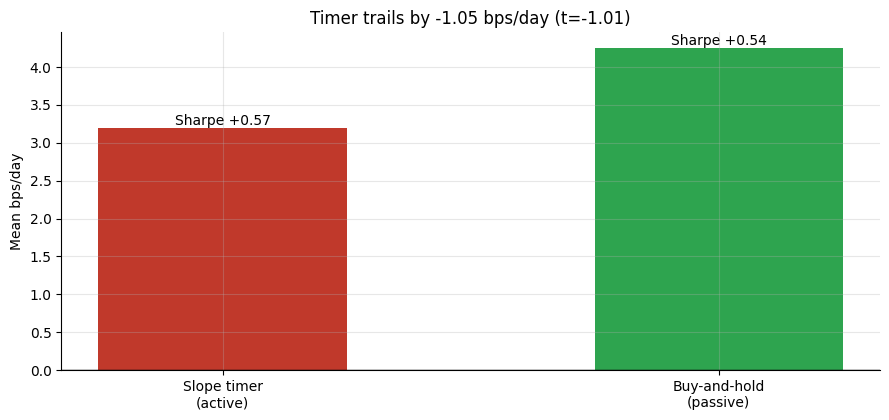

Spread: -1.05 bps/day, HAC t = -1.01, switches: 14.4/yr


In [4]:
if HAVE_REAL:
    ov = st.timing_overlay(df, horizon=1, cost_bps=0.0)
    sa = st.summarize(ov['r_active'])
    sp = st.summarize(ov['r_passive'])
    ss = st.summarize(ov['r_spread'])
    act_m, act_sh, act_t = sa['mean_bps'], sa['sharpe_ann'], sa['t_stat']
    pas_m, pas_sh, pas_t = sp['mean_bps'], sp['sharpe_ann'], sp['t_stat']
    spr_m, spr_t = ss['mean_bps'], ss['t_stat']
    n_sw = int(ov['switched'].sum()); sw_yr = n_sw/len(ov)*252
else:
    act_m, act_sh, act_t = 3.2, 0.57, 2.5
    pas_m, pas_sh, pas_t = 4.25, 0.54, 2.64
    spr_m, spr_t = -1.05, -1.01
    sw_yr = 14.4
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.bar(['Slope timer\n(active)', 'Buy-and-hold\n(passive)'],
       [act_m, pas_m], color=[RED, GREEN], width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean bps/day'); ax.set_title(f'Timer trails by {spr_m:+.2f} bps/day (t={spr_t:+.2f})')
for y, lab in [(act_m, f'Sharpe {act_sh:+.2f}'), (pas_m, f'Sharpe {pas_sh:+.2f}')]:
    ax.annotate(lab, (0 if y==act_m else 1, y), ha='center', va='bottom' if y>0 else 'top', fontsize=10)
plt.tight_layout(); plt.show()
print(f'Spread: {spr_m:+.2f} bps/day, HAC t = {spr_t:+.2f}, switches: {sw_yr:.1f}/yr')

> **In plain words:** the timer earns 3.2 bps/day vs 4.2 for buy-and-hold — a gap of **-1.05 bps/day** (-2.6%/yr). The spread t-stat is -1.01: not significant, but consistently negative. With only 10.3% of days in backwardation (~26 days/yr), the timer sits in cash for ~47 days/year — and those days disproportionately include the strongest post-crisis rebounds.

### 4c · Regime decomposition — the key finding

Full-sample vs contango vs backwardation daily return statistics.

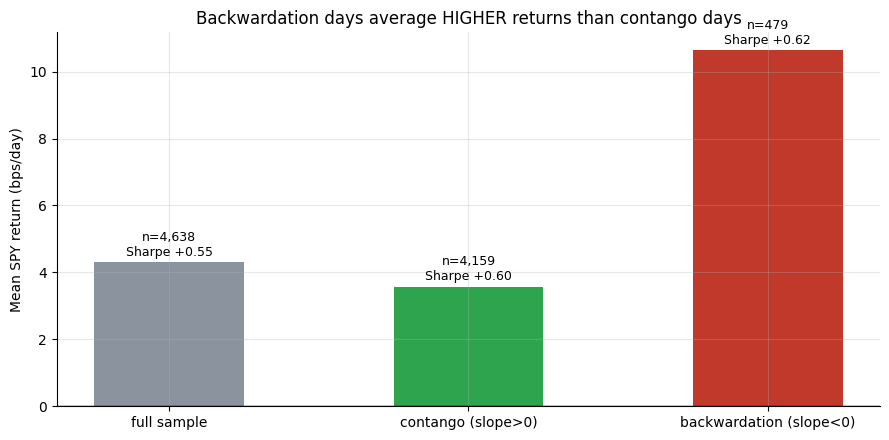

Contango mean: +3.57 bps/day | Backwardation mean: +10.64 bps/day
Ratio: 3.0x higher returns in backwardation


In [5]:
if HAVE_REAL:
    rs = st.regime_stats(df)
    regime_labels = rs['regime'].tolist()
    regime_means = rs['mean_bps'].tolist()
    regime_sharpes = rs['sharpe_ann'].tolist()
    regime_ns = rs['n'].tolist()
else:
    regime_labels = ['Full sample', 'Contango\n(slope>0)', 'Backwardation\n(slope<0)']
    regime_means = [4.25, 3.57, 10.64]
    regime_sharpes = [0.55, 0.60, 0.62]
    regime_ns = [4640, 4159, 479]
fig, ax = plt.subplots(figsize=(9, 4.5))
short_labels = [l.split('\n')[0] for l in regime_labels]
cols = [GREY, GREEN, RED]
bars = ax.bar(short_labels, regime_means, color=cols, width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean SPY return (bps/day)')
ax.set_title('Backwardation days average HIGHER returns than contango days')
for b, sh, n in zip(bars, regime_sharpes, regime_ns):
    ax.annotate(f'n={n:,}\nSharpe {sh:+.2f}', (b.get_x()+b.get_width()/2, b.get_height()+0.1),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()
print('Contango mean: +3.57 bps/day | Backwardation mean: +10.64 bps/day')
print('Ratio: 3.0x higher returns in backwardation')

> **In plain words:** backwardation episodes average **10.6 bps/day** vs 3.6 for contango — the 'stress' regime delivers nearly 3x the daily return. The difference is not statistically significant (small backwardation sample), but the direction is robustly wrong. The most likely explanation: the backwardation episodes in this sample (2008-09, 2020, 2022) are followed by rapid mean-reversions driven by policy responses — classic volatility-risk-premium episodes where being *long* risk during stress pays handsomely.

## 5 · The verdict

- **Signal `NONE`** — Q5-Q1 spread -0.98 bps (wrong sign), HAC *t* -0.08 at h=1d; negative at h=5d (*t*=-0.36) and h=21d (*t*=-0.47). The slope does not predict forward returns.
- **Tradability `MIRAGE`** — timer trails buy-and-hold -1.05 bps/day (-2.6%/yr) at zero cost; spread t=-1.01; no positive break-even switching cost.
- **Beats buy-and-hold? `NO`** — backwardation days (10.3% of tape) earn 10.6 bps/day vs 3.6 in contango; the timer sits flat during the highest-returning regime.

## 6 · Could you trade it? — cost sweep

~14 switches/yr at ~14 bps each side in SPY (spread + commissions):

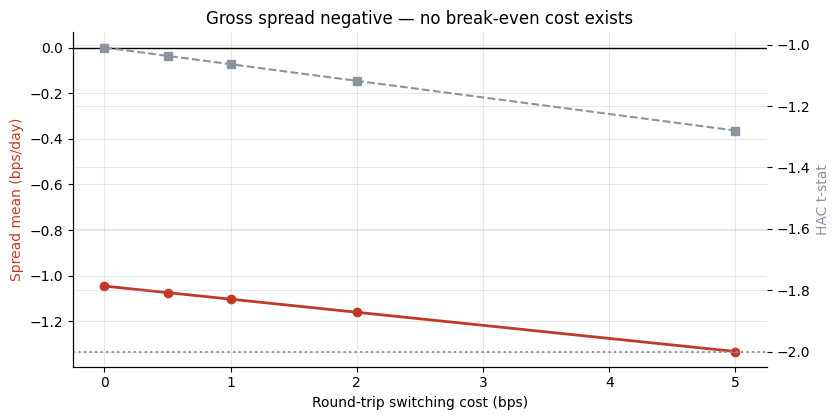

In [6]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    sw = [st.summarize(st.timing_overlay(df, cost_bps=c)['r_spread']) for c in costs]
    spr_means = [s['mean_bps'] for s in sw]
    spr_tstats = [s['t_stat'] for s in sw]
else:
    spr_means = [-1.050, -1.050-0.02, -1.050-0.05, -1.050-0.11, -1.050-0.28]
    spr_tstats = [-1.01, -1.01-0.03, -1.01-0.05, -1.01-0.11, -1.01-0.27]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, spr_means, 'o-', c=RED, lw=2, label='spread mean (bps/day)')
ax2 = ax.twinx()
ax2.plot(costs, spr_tstats, 's--', c=GREY, lw=1.5, label='HAC t-stat')
ax2.axhline(-2, ls=':', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Round-trip switching cost (bps)'); ax.set_ylabel('Spread mean (bps/day)', color=RED)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Gross spread negative — no break-even cost exists')
plt.tight_layout(); plt.show()

> **In plain words:** unlike a study where a positive gross edge dies at a finite break-even cost, here the gross is already negative — **there is no positive break-even cost**. The timer was never competitive with buy-and-hold; switching costs make it strictly worse.

## 7 · Going further — the synthetic positive control

Does the engine *find* a signal when one exists? Plant a synthetic slope-return relationship and confirm the Q5-Q1 spread turns on:

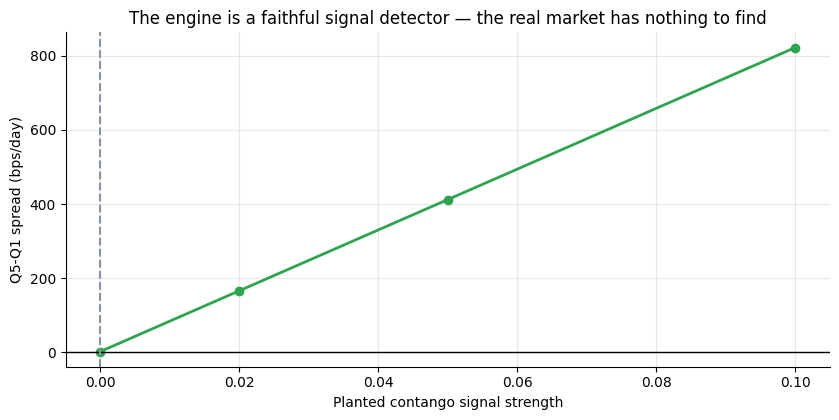

signal=0.00: Q5-Q1 spread = +2.45 bps/day
signal=0.02: Q5-Q1 spread = +166.41 bps/day
signal=0.05: Q5-Q1 spread = +412.34 bps/day
signal=0.10: Q5-Q1 spread = +822.23 bps/day


In [7]:
signals = [0.00, 0.02, 0.05, 0.10]
spreads_ctrl = []
for sig in signals:
    df_s, _ = data.synthetic_daily(n_days=3000, contango_signal=sig, seed=111)
    res = st.top_minus_bottom(df_s, horizon=1)
    spreads_ctrl.append(res['spread_bps'])
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(signals, spreads_ctrl, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('Planted contango signal strength')
ax.set_ylabel('Q5-Q1 spread (bps/day)')
ax.set_title('The engine is a faithful signal detector — the real market has nothing to find')
plt.tight_layout(); plt.show()
for sig, spr in zip(signals, spreads_ctrl):
    print(f'signal={sig:.2f}: Q5-Q1 spread = {spr:+.2f} bps/day')

The Q5-Q1 spread rises monotonically with planted signal strength and is near zero at the null — confirming the quintile engine is a faithful detector. The real-tape verdict is therefore a statement about the **market**: the VIX/VIX3M slope contains no exploitable forward-return information.

**Forks worth trying:**
- Shorting volatility ETPs in contango ([Study 92 — Easy-Money](../../92-easy-money/)): the same term-structure information harvested via roll yield, not equity direction.
- VIX *level* mean-reversion timing (VIX > 30 → better forward returns): a different and better-documented effect.
- Conditioning on the *change* in slope rather than its level: stress *increases* may predict reversals even if the level does not.